## **UNIQ Earth Sciences 2026**
### **Practical:** Climate Change and Coral Reefs

### **Overview**

In this practical session we will use a simple, global-mean climate model to explore the sensitivity of Earth's climate to variations in greenhouse gases, aerosols and natural forcing (volcanic eruptions). 

The simple globally-averged climate model is called the `Finite-amplitude Impulse Response` model, or `FaIR` for short. It allows the user to input emissions of greenhouse gases and short lived climate forcers in order to estimate global mean **atmospheric greenhouse gas (GHG) concentrations**, **radiative forcing** and **temperature anomalies**.

For more information on FaIR, see the [documentation](https://docs.fairmodel.net/en/latest/).

The objective of these exercises is to consolidate your understanding of basic climate change concepts, rather than to learn Python!  Therefore, this notebook contains all the code you will need, and only minor changes to the model inputs will be required to answer the questions below. Note that changes will not be saved in these notebooks, so you will need to keep a separate record of your responses to the questions below (which appear in <span style="color:blue">blue</span>) and of any input parameters you want to remember.

<br>

***Acknowledgements:** Thanks to Peter Watson and Myles Allen for creating the first iteration of these notebooks, Helen Johnson for creating the second iteration, and to the `FaIR` development team for making the model available.*


</br>
</br>

# 1. Climate and CO2 concentrations

In this section we start by driving the model with atmospheric CO2 concentrations (not thinking about emissions yet!), to understand how global-mean temperature responds to idealized changes in the level of CO2 in the atmosphere. First, we examine the response to an instantaneous step-change in CO2 concentrations, and investigate the concept of the *Equilibrium Climate Sensitivity* (ECS). Then we examine the response of global-mean temperature to a "ramp-up" scenario, where we slowly increase the concentration of atmospheric CO2 over time. This motivates the need to consider the *Transient Climate Response* (or TCR).

A reminder of the definitions:

**Equilibrium Climate Sensitivity (ECS)** - equilibrium warming after CO2 concentrations are doubled and then held constant indefinitely.

**Transient Climate Response (TCR)** - warming at the time of CO2 doubling following an exponential rise in CO2 concentrations by 1%/year.


### **Basic Imports**

- **Numpy** is a library built on top of C which allows you to perform rapid numerical calculations in Python and generate/manipulate arrays and matrices in a similar way to in MATLAB. <br>


- **Matplotlib** is the canonical plotting package in Python; as you might have guessed by the name, it's basically an open-source version of MATLAB's plotting functions. <br>
    - The '%matplotlib inline' comment just allows normal plotting within the Jupyter notebooks

In [1]:
%matplotlib inline

Now increase the equilibrium climate sensitivity (ECS) to 5K (the top of the likely range given by the IPCC 6th assessment report) in block B under Section 5. 

 - <span style="color:blue">How does this change the relationship between cumulative CO2 emissions and temperature, and why? What are the implications for predicting long-term climate change?</span>

In [80]:
import numpy as np
import matplotlib.pyplot as pl
import pandas as pd

from fair import FAIR
from fair.io import read_properties
from fair.interface import fill, initialise
from fair.earth_params import seconds_per_year

# CREATE SIMULATION
f = FAIR() # Create a new model instance
f.define_time(1750, 2100, 1) # Run simulation from 1750 to 2100
seed = 123456 # Random seed

# Set up different SSP scenarios as SCENARIOS
f.define_scenarios(['ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp534-over', 'ssp585']) # Consider key CMIP6 SSPs

# Set up different GCM configurations as CONFIGS
df = pd.read_csv("../data/4xCO2_cummins_ebm3.csv")
models = df['model'].unique()
configs = []
for imodel, model in enumerate(models):
    for run in df.loc[df['model']==model, 'run']:
        configs.append(f"{model}_{run}")
f.define_configs(configs)

# Set up different GHG species as SPECIES
species, properties = read_properties()
f.define_species(species, properties)

f.allocate() # Allocate input and output data

# CONFIGURE SIMULATION
# Import default GHG parameters into model
f.fill_species_configs()

# Import CMIP6 model-specific parameters
for config in configs:
    model, run = config.split('_')
    condition = (df['model']==model) & (df['run']==run)
    fill(f.climate_configs['ocean_heat_capacity'], df.loc[condition, 'C1':'C3'].values.squeeze(), config=config)
    fill(f.climate_configs['ocean_heat_transfer'], df.loc[condition, 'kappa1':'kappa3'].values.squeeze(), config=config)
    fill(f.climate_configs['deep_ocean_efficacy'], df.loc[condition, 'epsilon'].values[0], config=config)
    fill(f.climate_configs['gamma_autocorrelation'], df.loc[condition, 'gamma'].values[0], config=config)
    fill(f.climate_configs['sigma_eta'], df.loc[condition, 'sigma_eta'].values[0], config=config)
    fill(f.climate_configs['sigma_xi'], df.loc[condition, 'sigma_xi'].values[0], config=config)
    fill(f.climate_configs['stochastic_run'], True, config=config)
    fill(f.climate_configs['use_seed'], True, config=config)
    fill(f.climate_configs['seed'], seed, config=config)
    seed = seed + 399

# Set up SSP scenarios
f.fill_from_rcmip()
initialise(f.concentration, f.species_configs['baseline_concentration'])
initialise(f.forcing, 0)
initialise(f.temperature, 0)
initialise(f.cumulative_emissions, 0)
initialise(f.airborne_emissions, 0)

In [81]:
f.run()

Running 396 projections in parallel:   0%|          | 0/350 [00:00<?, ?timesteps/s]

Text(0, 0.5, 'Temperature anomaly (K)')

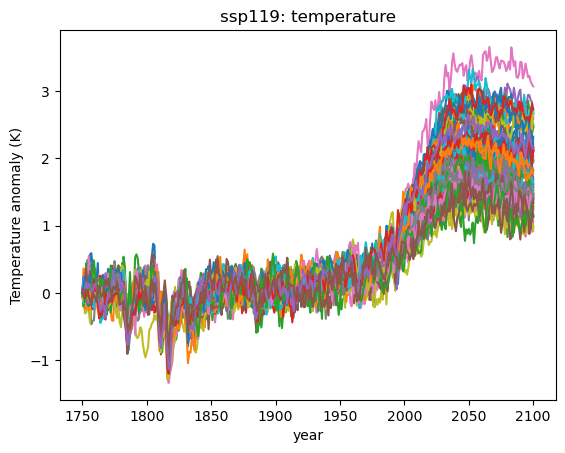

In [76]:
pl.plot(f.timebounds, f.temperature.loc[dict(scenario='ssp119', layer=0)], label=f.configs);
pl.title('ssp119: temperature')
pl.xlabel('year')
pl.ylabel('Temperature anomaly (K)')

In [42]:
f.run()

ValueError: There are NaN values in FAIR.climate_configs['ocean_heat_capacity']